# 7 -  Prior Sensitivity Analysis

Examine how the posterior GMSL estimate and recovered ice-thickness field
respond to changes in the prior: correlation length scale, mean offset
(via `gmsl_target_mean`), and covariance amplitude (via `ice_gmsl_std`).

## Setup

Import libraries, configure plotting, and initialise the fingerprint model.

In [1]:
import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from scipy import stats
from tqdm import tqdm
from pygeoinf import (
    CholeskySolver,
    CGMatrixSolver,
    GaussianMeasure,
    LinearBayesianInversion,
    LinearForwardProblem,
)
from pyslfp import (
    FingerPrint,
    IceModel,
    averaging_operator,
)

from project import colors
from pygeoinf_extras import standard_dev
from pygeoinf_extras.operators import (
    point_averaging_operator,
)
from pyslfp_extras.ice_thickness import IceSheetChange
from pyslfp_extras.plotting import plot

# --- Plotting style ---
sns.set_theme("paper")
sns.set_style("ticks")

fig_format = "png"
NOTEBOOK_DIR = Path.cwd()
FIGURES_DIR = NOTEBOOK_DIR / "figures" / fig_format
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Notebook directory: /Users/th/Documents/pt-3-project/notebooks
Figures will be saved to: /Users/th/Documents/pt-3-project/notebooks/figures/png


## Define Forward Model

Build the forward-operator chain used throughout the sensitivity tests:
ice thickness $\to$ surface mass load $\to$ sea-level fingerprint $\to$
altimetry point estimations.

The `IceSheetChange` class encapsulates the model space, prior measure,
and all operator chains.  A single "truth" instance is created first; the
sensitivity sweeps then build new instances with varied prior parameters
while reusing the same fingerprint and observation geometry.

In [2]:
lmax = 128
altimetry_degree_density = 5.0

# --- Initialise fingerprint model ---
fp = FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

# --- Truth prior: moderate length scale, small GMSL std ---
truth_length_scale = 0.1 * fp.mean_sea_floor_radius
truth_gmsl_std = 0.01

truth_ice_change = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=truth_length_scale,
    pattern=IceSheetChange.ThicknessWeightedPattern(),
    ice_gmsl_std=truth_gmsl_std,
    point_degree_spacing=altimetry_degree_density,
)

# --- Operators used everywhere ---
model_space = truth_ice_change.ice_thickness.domain
data_space = (
    truth_ice_change.load_to_ssh_point_estimations_operator
    @ truth_ice_change.ice_thickness_to_load_operator
).codomain

# Sea-level conversion (for spatial plots)
ice_thickness_to_slc_op = (
    truth_ice_change.load_to_slc_operator
    @ truth_ice_change.ice_thickness_to_load_operator
)

# GMSL property operator (mm)
GMSL_weighting_function = (
    -fp.ice_density
    * fp.one_minus_ocean_function
    * fp.ice_projection(value=0)
    * 1000
    * fp.length_scale
    / (fp.water_density * fp.ocean_area)
)
B = averaging_operator(
    model_space, [GMSL_weighting_function]
)

# Point-averaging operator for altimetric GMSL comparison
F = point_averaging_operator(data_space)

print(
    f"Forward operator: {model_space.dim} -> {data_space.dim}"
)

Forward operator: 16641 -> 1402


## Generate Synthetic Truth and Data

Draw a synthetic ice-thickness field from the truth prior and produce
noisy altimetry observations.

In [3]:
# --- Data error ---
altimetry_std_dev = 0.001
data_error_measure = (
    GaussianMeasure.from_standard_deviation(
        data_space, altimetry_std_dev
    )
)

# --- Build the forward operator from the truth instance ---
truth_forward_op = (
    truth_ice_change.load_to_ssh_point_estimations_operator
    @ truth_ice_change.ice_thickness_to_load_operator
)

# --- Forward problem ---
forward_problem = LinearForwardProblem(
    truth_forward_op, data_error_measure=data_error_measure
)

# --- Draw truth ---
truth_prior_measure = truth_ice_change.ice_thickness
np.random.seed(76)
model_true, data = forward_problem.synthetic_model_and_data(
    truth_prior_measure
)

# --- True GMSL ---
GMSL_true = B(model_true)[0]
print(f"True GMSL contribution: {GMSL_true:.4f} mm")

# --- Altimetry point estimation ---
ssh_estimation_alt = (
    truth_ice_change.load_to_point_estimated_gmsl_operator(
        truth_ice_change.ice_thickness_to_load_operator(
            model_true
        )
    )[0]
    * 1000
)
print(
    f"Altimetry point estimation: {ssh_estimation_alt:.4f} mm"
)

True GMSL contribution: 0.3764 mm
Altimetry point estimation: 0.3266 mm


## Visualise the Synthetic Truth

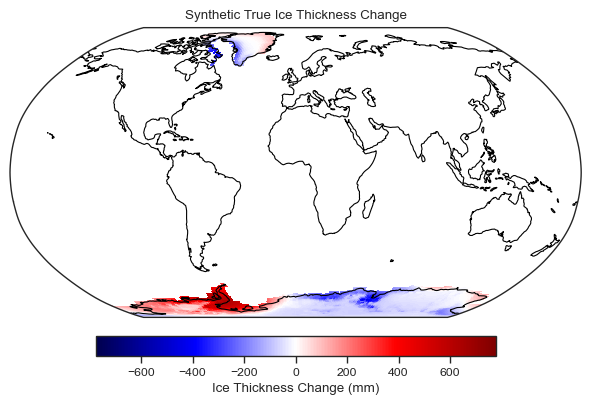

In [4]:
fig, ax, im = plot(
    model_true
    * fp.length_scale
    * 1000
    * fp.ice_projection(),
    coasts=True,
    cmap="seismic",
    symmetric=True,
    colorbar_label="Ice Thickness Change (mm)",
)
ax.set_title("Synthetic True Ice Thickness Change")
fig.savefig(
    FIGURES_DIR / f"7-0_true_ice_thickness.{fig_format}",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Inversion Helper

A small utility that, given an `IceSheetChange` instance, builds the
forward problem and runs the Bayesian inversion against the shared
synthetic data.

In [5]:
def run_inversion(ice_change: IceSheetChange):
    """Run a Bayesian inversion for the given IceSheetChange prior and
    return (model_posterior_measure, prior_measure)."""
    fwd_op = (
        ice_change.load_to_ssh_point_estimations_operator
        @ ice_change.ice_thickness_to_load_operator
    )
    fwd_problem = LinearForwardProblem(
        fwd_op, data_error_measure=data_error_measure
    )
    prior = ice_change.ice_thickness
    inversion = LinearBayesianInversion(fwd_problem, prior)
    residuals = []

    pbar = tqdm(desc="CG solve")

    def progress_callback(xk):
        residuals.append(np.linalg.norm(xk))
        pbar.set_postfix({"||x||": f"{residuals[-1]:.2e}"})
        pbar.update(1)

    returnable = (
        inversion.model_posterior_measure(
            data,
            CGMatrixSolver(callback=progress_callback),
        ),
        prior,
    )

    pbar.close()

    return returnable

In [12]:
def plot_gmsl_sensitivity(
    prior_measures,
    posterior_measures,
    param_values,
    param_label: str,
    panel_labels: list[str],
    suptitle: str,
    filename: str,
    fixed_x_range: tuple[float, float] | None = None,
):
    """Plot prior and posterior GMSL distributions for a sensitivity sweep."""
    GMSL_posts = [
        m.affine_mapping(operator=B)
        for m in posterior_measures
    ]
    # Calculate altimetry point estimation error
    averaged_error = data_error_measure.affine_mapping(
        operator=F
    )
    ssh_std = standard_dev(averaged_error) * 1000

    fig, axes = plt.subplots(
        1,
        len(param_values),
        figsize=(5 * len(param_values), 4),
    )
    if len(param_values) == 1:
        axes = [axes]

    for idx, ax in enumerate(axes):
        post_mean = GMSL_posts[idx].expectation[0]
        post_std = np.sqrt(
            GMSL_posts[idx].covariance.matrix(dense=True)[
                0, 0
            ]
        )

        if fixed_x_range is not None:
            x = np.linspace(*fixed_x_range, 500)
        else:
            x_lo = min(
                post_mean - 4 * post_std,
                ssh_estimation_alt - 4 * ssh_std,
                GMSL_true - 0.2 * abs(GMSL_true),
            )
            x_hi = max(
                post_mean + 4 * post_std,
                ssh_estimation_alt + 4 * ssh_std,
                GMSL_true + 0.2 * abs(GMSL_true),
            )
            x = np.linspace(x_lo, x_hi, 500)
        # hide y axis
        ax.get_yaxis().set_visible(False)
        # Altimetry point estimation
        alt_pdf = stats.norm.pdf(
            x, ssh_estimation_alt, ssh_std
        )
        ax.fill_between(
            x, alt_pdf, color=colors.old_method, alpha=0.25
        )
        ax.plot(
            x,
            alt_pdf,
            color=colors.old_method,
            lw=2,
            label="Altimetry",
        )

        # Posterior
        post_pdf = stats.norm.pdf(x, post_mean, post_std)
        ax.fill_between(
            x, post_pdf, color=colors.new_method, alpha=0.25
        )
        ax.plot(
            x,
            post_pdf,
            color=colors.new_method,
            lw=2,
            label="Posterior",
        )

        # True value
        ax.axvline(
            GMSL_true,
            color=colors.true,
            ls="--",
            lw=2,
            label=f"True ({GMSL_true:.2f} mm)",
        )

        ax.set_xlabel("GMSL Contribution (mm)")
        ax.set_ylabel("Probability Density")
        ax.set_title(
            f"{panel_labels[idx]} {param_label}: {param_values[idx]}"
        )
        if idx == 0:
            ax.legend(loc="best", fontsize=8)

    sns.despine(fig=fig)
    fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{filename}.{fig_format}",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()

## 1. Sensitivity to Prior Length Scale

Vary the correlation length scale of the prior while keeping
`ice_gmsl_std` fixed.  Inside `_build_measure`, the heat-kernel
covariance is rescaled so that the GMSL marginal standard deviation
always equals `ice_gmsl_std`; therefore the length scale controls
*only* the spatial correlation structure of the prior.

In [7]:
length_scales_km = np.array([80, 400, 2500])

prior_measures_ls = []
posterior_measures_ls = []

for scale_km in length_scales_km:
    print(f"\nLength scale: {scale_km} km")
    scale_nd = scale_km * 1000 / fp.length_scale

    ic = IceSheetChange.global_ice(
        finger_print=fp,
        finger_print_operator=fp_op,
        length_scale=scale_nd,
        pattern=IceSheetChange.ThicknessWeightedPattern(),
        ice_gmsl_std=truth_gmsl_std,
        point_degree_spacing=altimetry_degree_density,
    )

    posterior, prior = run_inversion(ic)
    prior_measures_ls.append(prior)
    posterior_measures_ls.append(posterior)
    print("  Inversion complete")

print("\nAll length-scale inversions complete.")


Length scale: 80 km


CG solve: 133it [00:50,  2.63it/s, ||x||=3.83e+04]


  Inversion complete

Length scale: 400 km


CG solve: 98it [00:37,  2.61it/s, ||x||=3.83e+04]


  Inversion complete

Length scale: 2500 km


CG solve: 57it [00:22,  2.56it/s, ||x||=3.85e+04]

  Inversion complete

All length-scale inversions complete.


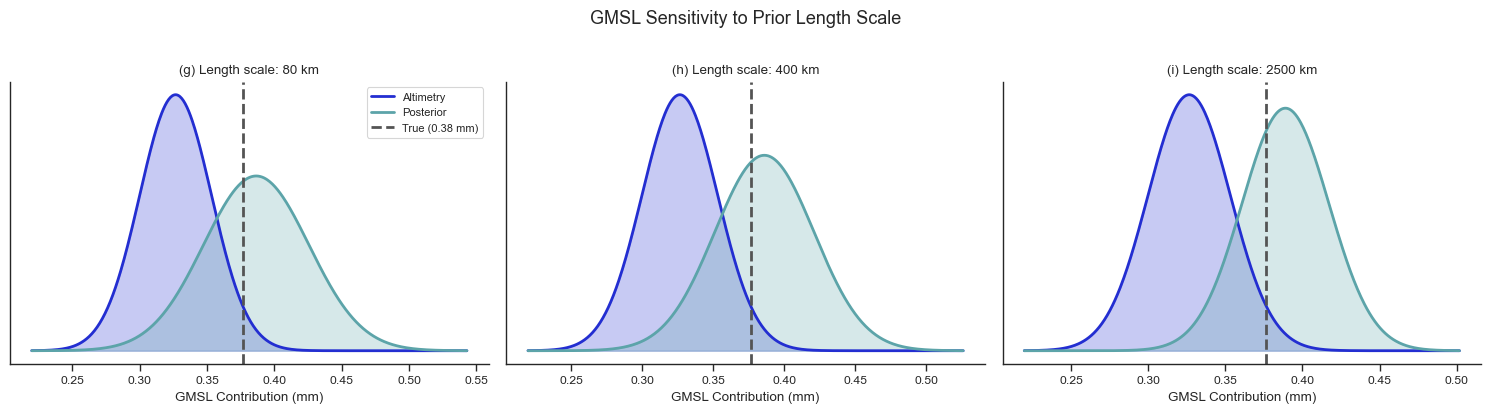

In [13]:
plot_gmsl_sensitivity(
    prior_measures_ls,
    posterior_measures_ls,
    param_values=[f"{v} km" for v in length_scales_km],
    param_label="Length scale",
    panel_labels=["(g)", "(h)", "(i)"],
    suptitle="GMSL Sensitivity to Prior Length Scale",
    filename="7-1_length_scale",
)

## 2. Sensitivity to Prior Mean

Shift the prior mean via the `gmsl_target_mean` parameter.
`_build_measure` computes a spatially-weighted uniform offset over the
ice extent so that the prior-mean GMSL equals the requested target.
The target is specified in non-dimensional units; we convert from mm.

In [9]:
offsets_mm = np.array([0.05, 0.2, 1.0])

prior_measures_off = []
posterior_measures_off = []

for offset_mm in offsets_mm:
    print(f"\nGMSL target mean: {offset_mm} mm")
    target_nd = offset_mm / (1000 * fp.length_scale)

    ic = IceSheetChange.global_ice(
        finger_print=fp,
        finger_print_operator=fp_op,
        length_scale=truth_length_scale,
        pattern=IceSheetChange.ThicknessWeightedPattern(),
        ice_gmsl_std=truth_gmsl_std,
        gmsl_target_mean=target_nd,
        point_degree_spacing=altimetry_degree_density,
    )

    posterior, prior = run_inversion(ic)
    prior_measures_off.append(prior)
    posterior_measures_off.append(posterior)
    print("  Inversion complete")

print("\nAll mean-offset inversions complete.")


GMSL target mean: 0.05 mm


CG solve: 107it [00:41,  2.61it/s, ||x||=3.83e+04]


  Inversion complete

GMSL target mean: 0.2 mm


CG solve: 123it [00:46,  2.62it/s, ||x||=3.83e+04]


  Inversion complete

GMSL target mean: 1.0 mm


CG solve: 83it [00:32,  2.58it/s, ||x||=3.83e+04]

  Inversion complete

All mean-offset inversions complete.


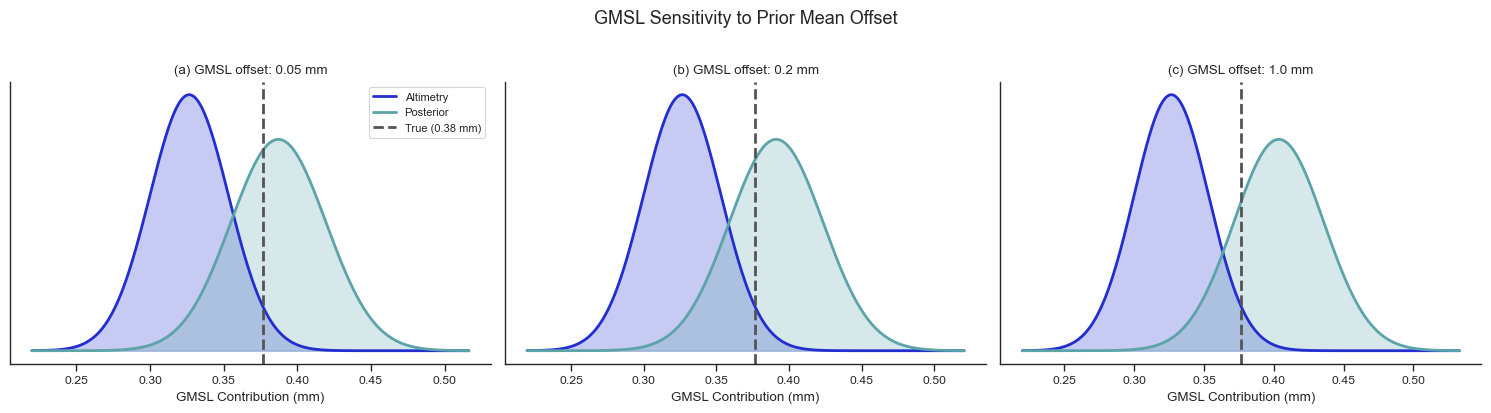

In [14]:
plot_gmsl_sensitivity(
    prior_measures_off,
    posterior_measures_off,
    param_values=[f"{v} mm" for v in offsets_mm],
    param_label="GMSL offset",
    panel_labels=["(a)", "(b)", "(c)"],
    suptitle="GMSL Sensitivity to Prior Mean Offset",
    filename="7-2_mean_translation",
)

## 3. Sensitivity to Prior Covariance Amplitude

Scale `ice_gmsl_std` by a multiplicative factor.  Because
`_build_measure` normalises the heat-kernel covariance so that the
GMSL marginal standard deviation equals `ice_gmsl_std`, this directly
controls how uncertain the prior is in GMSL space.

In [15]:
std_multipliers = np.array([0.5, 1.0, 2.0])

prior_measures_cov = []
posterior_measures_cov = []

for mult in std_multipliers:
    print(f"\nStd multiplier: {mult}")

    ic = IceSheetChange.global_ice(
        finger_print=fp,
        finger_print_operator=fp_op,
        length_scale=truth_length_scale,
        pattern=IceSheetChange.ThicknessWeightedPattern(),
        ice_gmsl_std=truth_gmsl_std * mult,
        point_degree_spacing=altimetry_degree_density,
    )

    posterior, prior = run_inversion(ic)
    prior_measures_cov.append(prior)
    posterior_measures_cov.append(posterior)
    print("  Inversion complete")

print("\nAll covariance-scaling inversions complete.")


Std multiplier: 0.5


CG solve: 62it [00:24,  2.56it/s, ||x||=3.84e+04]


  Inversion complete

Std multiplier: 1.0


CG solve: 114it [00:43,  2.61it/s, ||x||=3.83e+04]


  Inversion complete

Std multiplier: 2.0


CG solve: 318it [02:01,  2.62it/s, ||x||=3.83e+04]

  Inversion complete

All covariance-scaling inversions complete.


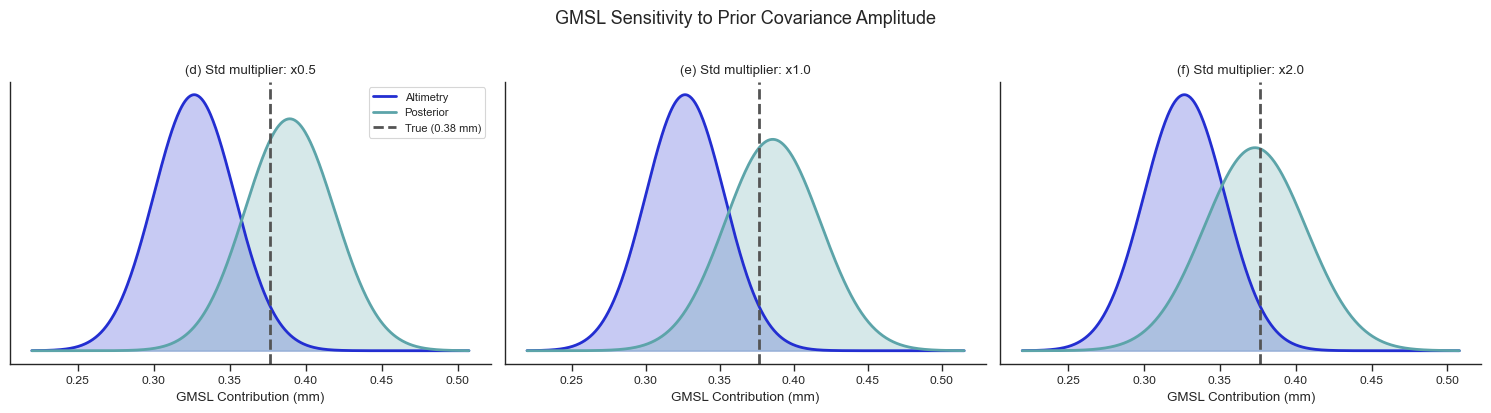

In [19]:
plot_gmsl_sensitivity(
    prior_measures_cov,
    posterior_measures_cov,
    param_values=[f"x{v}" for v in std_multipliers],
    param_label="Std multiplier",
    panel_labels=["(d)", "(e)", "(f)"],
    suptitle="GMSL Sensitivity to Prior Covariance Amplitude",
    filename="7-3_covariance_scaling",
)